**Import Libraries**

In [1]:
!pip install imbalanced-learn

In [2]:
# Cell 1: Import all necessary libraries
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_sample_weight
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Set style for better looking plots
plt.style.use('ggplot')
sns.set_palette("Set2")

print("All libraries imported successfully!")

All libraries imported successfully!


**Load and Explore Data**

In [3]:
# Cell 2: Load and explore the data
df = pd.read_csv('diabetes_dataset1.csv')

print("="*60)
print("DATASET INFORMATION")
print("="*60)
print(f"Dataset Shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print("\n")

print("First 5 rows:")
print(df.head())
print("\n")

print("Column names:")
print(df.columns.tolist())
print("\n")

print("Data types:")
print(df.dtypes)

DATASET INFORMATION
Dataset Shape: (42455, 16)
Number of rows: 42455
Number of columns: 16


First 5 rows:
   year  gender   age location  race:AfricanAmerican  race:Asian  \
0  2020  Female  32.0  Alabama                     0           0   
1  2015  Female  29.0  Alabama                     0           1   
2  2015    Male  18.0  Alabama                     0           0   
3  2015    Male  41.0  Alabama                     0           0   
4  2016  Female  52.0  Alabama                     1           0   

   race:Caucasian  race:Hispanic  race:Other  hypertension  heart_disease  \
0               0              0           1             0              0   
1               0              0           0             0              0   
2               0              0           1             0              0   
3               1              0           0             0              0   
4               0              0           0             0              0   

  smoking_history    

**Check and Handle Missing Values**

In [4]:
# Cell 3: Check for missing values
print("="*60)
print("MISSING VALUES CHECK")
print("="*60)

missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percent
})
print(missing_df[missing_df['Missing Values'] > 0])
print("\n")

# Handle missing values
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print(f"Missing values handled! Remaining: {df.isnull().sum().sum()}")

MISSING VALUES CHECK
Empty DataFrame
Columns: [Missing Values, Percentage]
Index: []


Missing values handled! Remaining: 0


**Remove Duplicates**

In [5]:
# Cell 4: Check and remove duplicates
print("="*60)
print("DUPLICATES CHECK")
print("="*60)

duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"Removed {duplicates} duplicate rows")
    print(f"New dataset shape: {df.shape}")
else:
    print("No duplicates found")

DUPLICATES CHECK
Number of duplicate rows: 4
Removed 4 duplicate rows
New dataset shape: (42451, 16)


**Handle Race Columns**

In [6]:
# Cell 5: Handle race columns
print("="*60)
print("HANDLING RACE COLUMNS")
print("="*60)

race_cols = [col for col in df.columns if col.startswith('race:')]
print(f"Race columns found: {race_cols}")

if race_cols:
    df['race'] = df[race_cols].idxmax(axis=1)
    df['race'] = df['race'].str.replace('race:', '')
    df.drop(columns=race_cols, inplace=True)
    print(f"Combined {len(race_cols)} race columns into single 'race' column")
    print(f"Race categories: {df['race'].unique().tolist()}")

HANDLING RACE COLUMNS
Race columns found: ['race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other']
Combined 5 race columns into single 'race' column
Race categories: ['Other', 'Asian', 'Caucasian', 'AfricanAmerican', 'Hispanic']


**Data Cleaning**

In [7]:
# Cell 6: Data cleaning
print("="*60)
print("DATA CLEANING")
print("="*60)

if 'smoking_history' in df.columns:
    df['smoking_history'] = df['smoking_history'].replace('No Info', 'unknown')
    print("Fixed smoking_history values")

if 'year' in df.columns:
    df['year'] = df['year'].astype(int)
    print(f"Year range: {df['year'].min()} - {df['year'].max()}")

# Fix invalid ages
if 'age' in df.columns:
    invalid_ages = df[(df['age'] < 0) | (df['age'] > 120)].shape[0]
    if invalid_ages > 0:
        df.loc[df['age'] < 0, 'age'] = df['age'].median()
        df.loc[df['age'] > 120, 'age'] = df['age'].median()
        print(f"Fixed {invalid_ages} invalid age values")

print("Data cleaning completed!")

DATA CLEANING
Fixed smoking_history values
Year range: 2015 - 2022
Data cleaning completed!


**Outlier Detection and Removal**

OUTLIER DETECTION AND REMOVAL
age: 0 outliers detected
bmi: 3021 outliers detected
hbA1c_level: 462 outliers detected
blood_glucose_level: 630 outliers detected


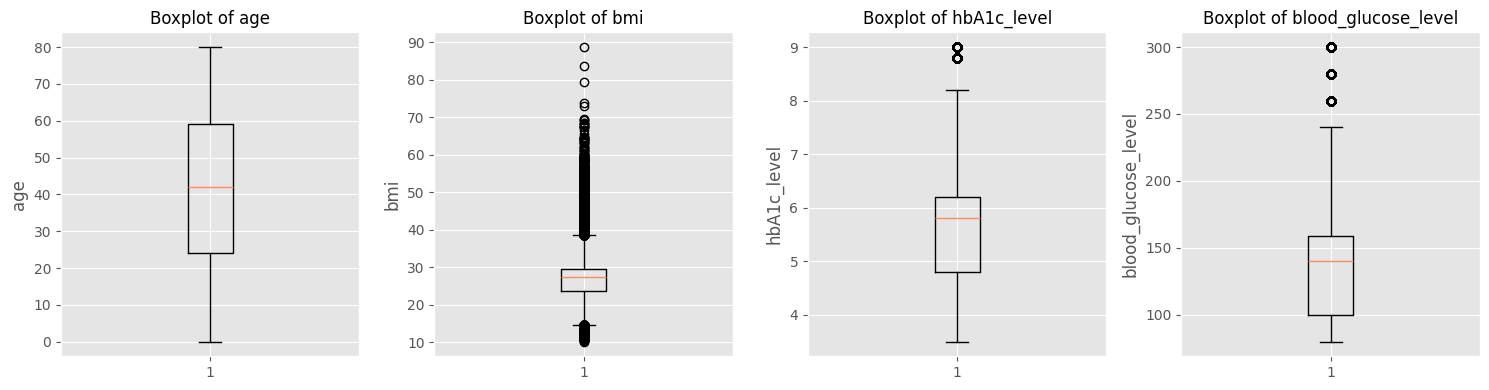


Initial shape: (42451, 12)
Shape after outlier removal: (38338, 12)
Removed 4113 rows


In [8]:
# Cell 7: Outlier detection and removal
print("="*60)
print("OUTLIER DETECTION AND REMOVAL")
print("="*60)

numeric_features = ['age', 'bmi', 'hbA1c_level', 'blood_glucose_level']
available_features = [col for col in numeric_features if col in df.columns]

fig, axes = plt.subplots(1, len(available_features), figsize=(15, 4))
if len(available_features) == 1:
    axes = [axes]

initial_shape = df.shape

for i, col in enumerate(available_features):
    axes[i].boxplot(df[col])
    axes[i].set_title(f'Boxplot of {col}', fontsize=12)
    axes[i].set_ylabel(col)

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    print(f"{col}: {outliers} outliers detected")

    # Remove outliers
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

plt.tight_layout()
plt.savefig('outlier_boxplots.png', dpi=100)
plt.show()

print(f"\nInitial shape: {initial_shape}")
print(f"Shape after outlier removal: {df.shape}")
print(f"Removed {initial_shape[0] - df.shape[0]} rows")

**Encode Categorical Variables**

In [9]:
# Cell 8: Encode categorical variables
print("="*60)
print("ENCODING CATEGORICAL VARIABLES")
print("="*60)

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")

label_encoders = {}

for col in categorical_cols:
    if col not in ['location', 'gender', 'race']:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le
        print(f"Label encoded: {col}")

# One-hot encode location, gender, race
cols_to_encode = ['location', 'gender', 'race']
cols_to_encode = [col for col in cols_to_encode if col in df.columns]

if cols_to_encode:
    df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)
    print(f"One-hot encoded: {cols_to_encode}")

print(f"\nFinal shape after encoding: {df.shape}")

ENCODING CATEGORICAL VARIABLES
Categorical columns: ['gender', 'location', 'smoking_history', 'race']
Label encoded: smoking_history
One-hot encoded: ['location', 'gender', 'race']

Final shape after encoding: (38338, 36)


**Prepare Features and Target**

In [10]:
# Cell 9: Prepare features and target for modeling
print("="*60)
print("PREPARING DATA FOR MODELING")
print("="*60)

target_col = 'diabetes'
X = df.drop(columns=[target_col])
y = df[target_col]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget distribution:")
print(f"Non-Diabetic (0): {(y==0).sum()} ({(y==0).sum()/len(y)*100:.2f}%)")
print(f"Diabetic (1): {(y==1).sum()} ({(y==1).sum()/len(y)*100:.2f}%)")

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

PREPARING DATA FOR MODELING
Features shape: (38338, 35)
Target shape: (38338,)

Target distribution:
Non-Diabetic (0): 36413 (94.98%)
Diabetic (1): 1925 (5.02%)

Training set size: 30670 samples
Testing set size: 7668 samples


**Feature Scaling**

In [11]:
# Cell 10: Feature scaling
print("="*60)
print("FEATURE SCALING")
print("="*60)

numeric_cols_for_scaling = X.select_dtypes(include=[np.number]).columns.tolist()

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols_for_scaling] = scaler.fit_transform(X_train[numeric_cols_for_scaling])
X_test_scaled[numeric_cols_for_scaling] = scaler.transform(X_test[numeric_cols_for_scaling])

print(f"Scaled {len(numeric_cols_for_scaling)} numeric features")

FEATURE SCALING
Scaled 8 numeric features


**Train and Compare Models**

In [12]:
# Cell 11: Train and compare models (FIXED - class imbalance handled)
print("="*60)
print("MODEL TRAINING AND COMPARISON")
print("="*60)

# SMOTE se balanced data banao (KNN ke liye)
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)
print(f"After SMOTE - Non-Diabetic: {(y_train_bal==0).sum()}, Diabetic: {(y_train_bal==1).sum()}")

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced')
}

results = []

for name, model in models.items():
    print(f"\nTraining {name}...", end=" ", flush=True)

    # KNN aur Gradient Boosting ke liye SMOTE data use karo
    if name in ['K-Nearest Neighbors', 'Gradient Boosting']:
        model.fit(X_train_bal, y_train_bal)
    else:
        model.fit(X_train_scaled, y_train)

    y_test_pred = model.predict(X_test_scaled)

    test_acc  = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred)
    recall    = recall_score(y_test, y_test_pred)
    f1        = f1_score(y_test, y_test_pred)

    results.append({
        'Model': name,
        'Test Accuracy': test_acc,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })

    print(f"Done (Acc: {test_acc:.4f}, Recall: {recall:.4f})")

results_df = pd.DataFrame(results).sort_values('F1 Score', ascending=False)
print("\n" + "="*60)
print("MODEL COMPARISON RESULTS")
print("="*60)
print(results_df.to_string(index=False))

best_model_name = results_df.iloc[0]['Model']
print(f"\n✅ BEST MODEL: {best_model_name}")

MODEL TRAINING AND COMPARISON
After SMOTE - Non-Diabetic: 29130, Diabetic: 29130

Training Logistic Regression... Done (Acc: 0.8481, Recall: 0.8312)

Training Random Forest... Done (Acc: 0.9734, Recall: 0.4805)

Training Gradient Boosting... Done (Acc: 0.9463, Recall: 0.6519)

Training K-Nearest Neighbors... Done (Acc: 0.8976, Recall: 0.5870)

Training Decision Tree... Done (Acc: 0.9545, Recall: 0.5766)

MODEL COMPARISON RESULTS
              Model  Test Accuracy  Precision   Recall  F1 Score
      Random Forest       0.973396   0.978836 0.480519  0.644599
      Decision Tree       0.954486   0.544118 0.576623  0.559899
  Gradient Boosting       0.946270   0.474480 0.651948  0.549234
K-Nearest Neighbors       0.897626   0.265258 0.587013  0.365400
Logistic Regression       0.848070   0.225352 0.831169  0.354571

✅ BEST MODEL: Random Forest


**Train Final Model**

In [13]:
# Cell 12: Train final best model (FIXED)
print("="*60)
print(f"TRAINING FINAL MODEL: {best_model_name}")
print("="*60)

if best_model_name == 'Random Forest':
    final_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    )
    final_model.fit(X_train_bal, y_train_bal)

elif best_model_name == 'Gradient Boosting':
    final_model = GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1,
        max_depth=5, random_state=42
    )
    final_model.fit(X_train_bal, y_train_bal)

elif best_model_name == 'Logistic Regression':
    final_model = LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced'
    )
    final_model.fit(X_train_scaled, y_train)

elif best_model_name == 'K-Nearest Neighbors':
    final_model = KNeighborsClassifier(n_neighbors=7)
    final_model.fit(X_train_bal, y_train_bal)

else:
    final_model = DecisionTreeClassifier(
        max_depth=10, random_state=42, class_weight='balanced'
    )
    final_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred = final_model.predict(X_train_scaled)
y_test_pred  = final_model.predict(X_test_scaled)

print(f"✅ Model training completed!")
print(f"Recall on test set: {recall_score(y_test, y_test_pred):.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")

TRAINING FINAL MODEL: Random Forest
✅ Model training completed!
Recall on test set: 0.7429
Accuracy: 0.9158


In [14]:
# Threshold test
from sklearn.metrics import classification_report

# Normal 0.5 threshold
y_pred_default = final_model.predict(X_test_scaled)

# Custom 0.3 threshold -- diabetic tabhi bolo jab 30% se zyada sure ho
y_pred_proba = final_model.predict_proba(X_test_scaled)[:, 1]
y_pred_custom = (y_pred_proba >= 0.3).astype(int)

print("Default threshold (0.5):")
print(classification_report(y_test, y_pred_default, target_names=['Non-Diabetic', 'Diabetic']))

print("Custom threshold (0.3):")
print(classification_report(y_test, y_pred_custom, target_names=['Non-Diabetic', 'Diabetic']))

Default threshold (0.5):
              precision    recall  f1-score   support

Non-Diabetic       0.99      0.92      0.95      7283
    Diabetic       0.34      0.74      0.47       385

    accuracy                           0.92      7668
   macro avg       0.66      0.83      0.71      7668
weighted avg       0.95      0.92      0.93      7668

Custom threshold (0.3):
              precision    recall  f1-score   support

Non-Diabetic       0.99      0.85      0.92      7283
    Diabetic       0.24      0.85      0.37       385

    accuracy                           0.85      7668
   macro avg       0.61      0.85      0.64      7668
weighted avg       0.95      0.85      0.89      7668



**Evaluate Final Model**

In [15]:
# Cell 13: Final model evaluation
print("="*60)
print("FINAL MODEL EVALUATION")
print("="*60)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("TRAINING METRICS:")
print(f"  Train Accuracy: {train_accuracy:.4f}")
print(f"  Test Accuracy: {test_accuracy:.4f}")

print("\nTESTING METRICS:")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"  F1 Score: {f1:.4f}")

print("\n" + "="*60)
print("CLASSIFICATION REPORT:")
print("="*60)
print(classification_report(y_test, y_test_pred, target_names=['Non-Diabetic', 'Diabetic']))

FINAL MODEL EVALUATION
TRAINING METRICS:
  Train Accuracy: 0.9351
  Test Accuracy: 0.9158

TESTING METRICS:
  Precision: 0.3433
  Recall: 0.7429
  F1 Score: 0.4696

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

Non-Diabetic       0.99      0.92      0.95      7283
    Diabetic       0.34      0.74      0.47       385

    accuracy                           0.92      7668
   macro avg       0.66      0.83      0.71      7668
weighted avg       0.95      0.92      0.93      7668



**Confusion Matrix**

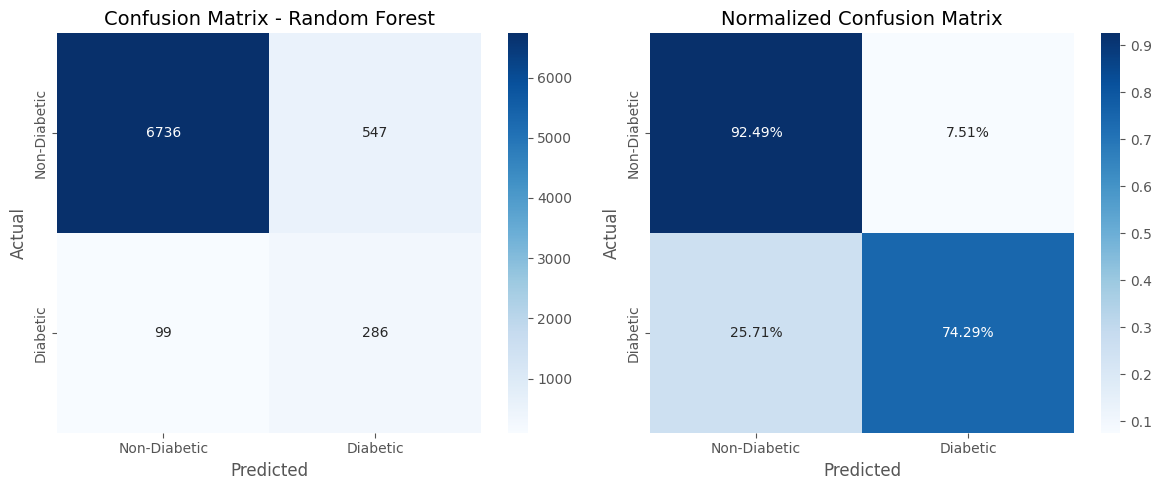


True Negatives: 6736
False Positives: 547
False Negatives: 99
True Positives: 286


In [16]:
# Cell 14: Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])
axes[0].set_title(f'Confusion Matrix - {best_model_name}', fontsize=14)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])
axes[1].set_title(f'Normalized Confusion Matrix', fontsize=14)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print(f"\nTrue Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")

**ROC Curve**

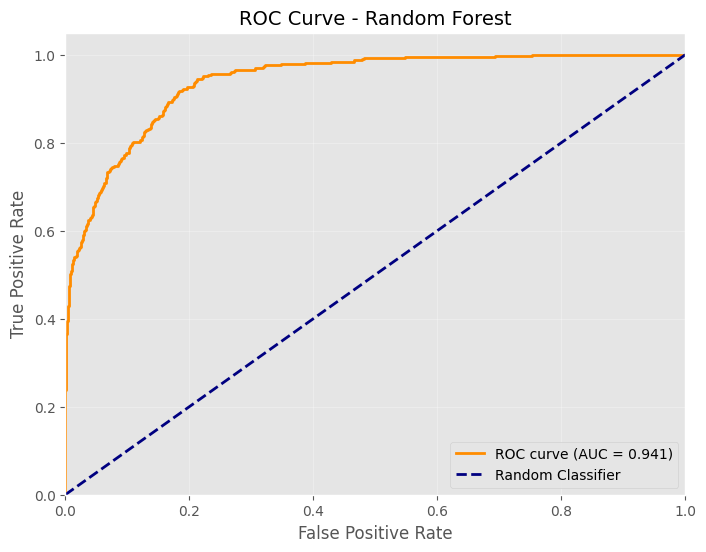

ROC-AUC Score: 0.9406


In [17]:
# Cell 15: ROC Curve
try:
    y_pred_proba = final_model.predict_proba(X_test_scaled)[:, 1]
except:
    from sklearn.calibration import CalibratedClassifierCV
    calibrated_model = CalibratedClassifierCV(final_model, cv=3)
    calibrated_model.fit(X_train_scaled, y_train)
    y_pred_proba = calibrated_model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - {best_model_name}', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.savefig('roc_curve.png', dpi=150)
plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")

**Feature Importance**

FEATURE IMPORTANCE
Top 10 Most Important Features:
                Feature  Importance
6           hbA1c_level    0.333171
1                   age    0.198652
7   blood_glucose_level    0.197117
5                   bmi    0.081611
4       smoking_history    0.055096
2          hypertension    0.022565
29          gender_Male    0.017388
3         heart_disease    0.017149
0                  year    0.009742
24      location_Kansas    0.004767


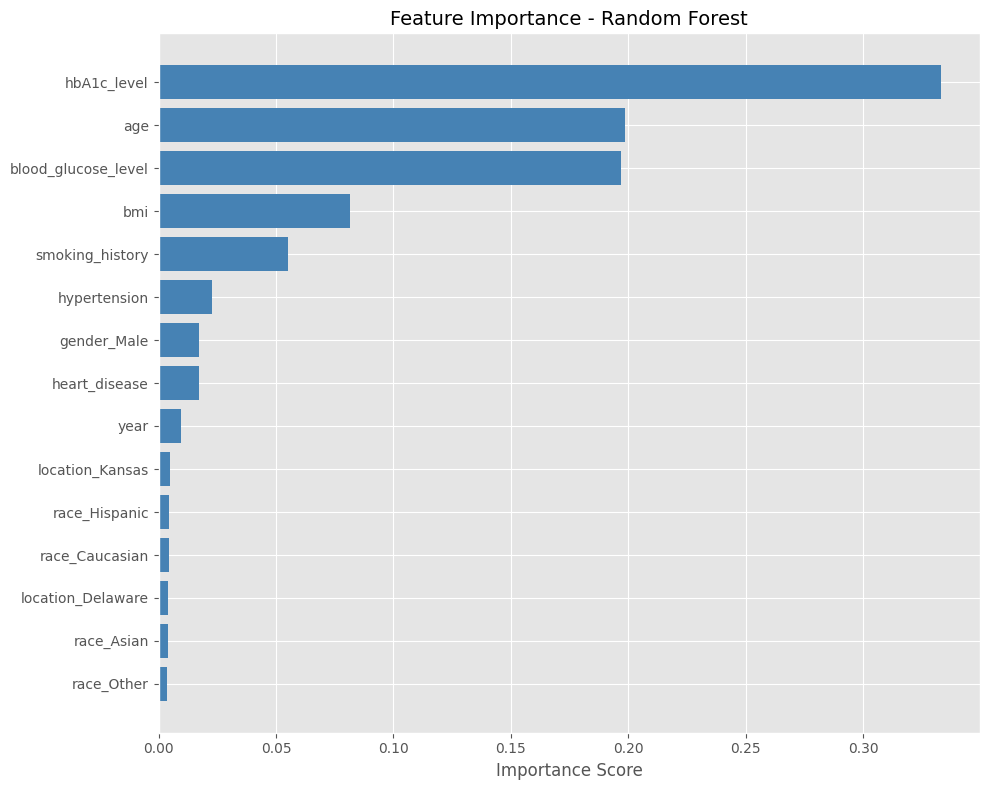

In [18]:
# Cell 16: Feature Importance
print("="*60)
print("FEATURE IMPORTANCE")
print("="*60)

if hasattr(final_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': final_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    print("Top 10 Most Important Features:")
    print(feature_importance.head(10))

    plt.figure(figsize=(10, 8))
    top_features = feature_importance.head(15)
    plt.barh(top_features['Feature'], top_features['Importance'], color='steelblue')
    plt.xlabel('Importance Score')
    plt.title(f'Feature Importance - {best_model_name}', fontsize=14)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150)
    plt.show()

**Save Model**

In [19]:
# Cell 17: Save model for future use
import joblib

print("="*60)
print("SAVING MODEL")
print("="*60)

joblib.dump(final_model, 'diabetes_prediction_model.pkl')
joblib.dump(scaler, 'diabetes_scaler.pkl')
joblib.dump(X.columns.tolist(), 'feature_columns.pkl')

print("Model saved as 'diabetes_prediction_model.pkl'")
print("Scaler saved as 'diabetes_scaler.pkl'")
print("Feature columns saved as 'feature_columns.pkl'")

SAVING MODEL
Model saved as 'diabetes_prediction_model.pkl'
Scaler saved as 'diabetes_scaler.pkl'
Feature columns saved as 'feature_columns.pkl'


**Prediction Function (Working)**

In [20]:
# Cell 18: Prediction function
print("="*60)
print("PREDICTION FUNCTION")
print("="*60)

feature_columns = X.columns.tolist()
feature_to_idx = {name: i for i, name in enumerate(feature_columns)}

def predict_diabetes(age, bmi, hba1c_level, blood_glucose_level):
    # Poori row banao
    input_array = np.zeros((1, len(feature_columns)))

    if 'age' in feature_to_idx:
        input_array[0, feature_to_idx['age']] = age
    if 'bmi' in feature_to_idx:
        input_array[0, feature_to_idx['bmi']] = bmi
    if 'hbA1c_level' in feature_to_idx:
        input_array[0, feature_to_idx['hbA1c_level']] = hba1c_level
    if 'blood_glucose_level' in feature_to_idx:
        input_array[0, feature_to_idx['blood_glucose_level']] = blood_glucose_level
    if 'year' in feature_to_idx:
        input_array[0, feature_to_idx['year']] = 2020
    if 'hypertension' in feature_to_idx:
        input_array[0, feature_to_idx['hypertension']] = 0
    if 'heart_disease' in feature_to_idx:
        input_array[0, feature_to_idx['heart_disease']] = 0
    if 'smoking_history' in feature_to_idx:
        input_array[0, feature_to_idx['smoking_history']] = 0
    if 'gender_Male' in feature_to_idx:
        input_array[0, feature_to_idx['gender_Male']] = 1
    for col in feature_columns:
        if col.startswith('location_'):
            input_array[0, feature_to_idx[col]] = 1 if col == 'location_Alabama' else 0
        if col.startswith('race_'):
            input_array[0, feature_to_idx[col]] = 1 if col == 'race_Caucasian' else 0

    # Sirf numeric columns scale karo — BILKUL training jaisa
    import pandas as pd
    input_df = pd.DataFrame(input_array, columns=feature_columns)
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])
    input_scaled = input_df.values

    # Predict
    probability = final_model.predict_proba(input_scaled)[0][1]
    prediction = 1 if probability >= 0.35 else 0
    result = "Diabetic" if prediction == 1 else "Non-Diabetic"
    risk = f"{probability*100:.1f}%"
    return result, risk

# Test karo
print("\nTesting:")
test_cases = [
    (25, 22.0, 5.0, 90),
    (28, 23.0, 5.2, 88),
    (55, 32.0, 7.5, 180),
    (65, 35.0, 8.5, 220),
]
for age, bmi, hba1c, glucose in test_cases:
    result, risk = predict_diabetes(age, bmi, hba1c, glucose)
    print(f"Age:{age} BMI:{bmi} HbA1c:{hba1c} Glucose:{glucose} → {result} ({risk})")

PREDICTION FUNCTION

Testing:
Age:25 BMI:22.0 HbA1c:5.0 Glucose:90 → Non-Diabetic (0.6%)
Age:28 BMI:23.0 HbA1c:5.2 Glucose:88 → Non-Diabetic (0.6%)
Age:55 BMI:32.0 HbA1c:7.5 Glucose:180 → Diabetic (90.0%)
Age:65 BMI:35.0 HbA1c:8.5 Glucose:220 → Diabetic (96.0%)


**Final Summary Graph**

FINAL SUMMARY


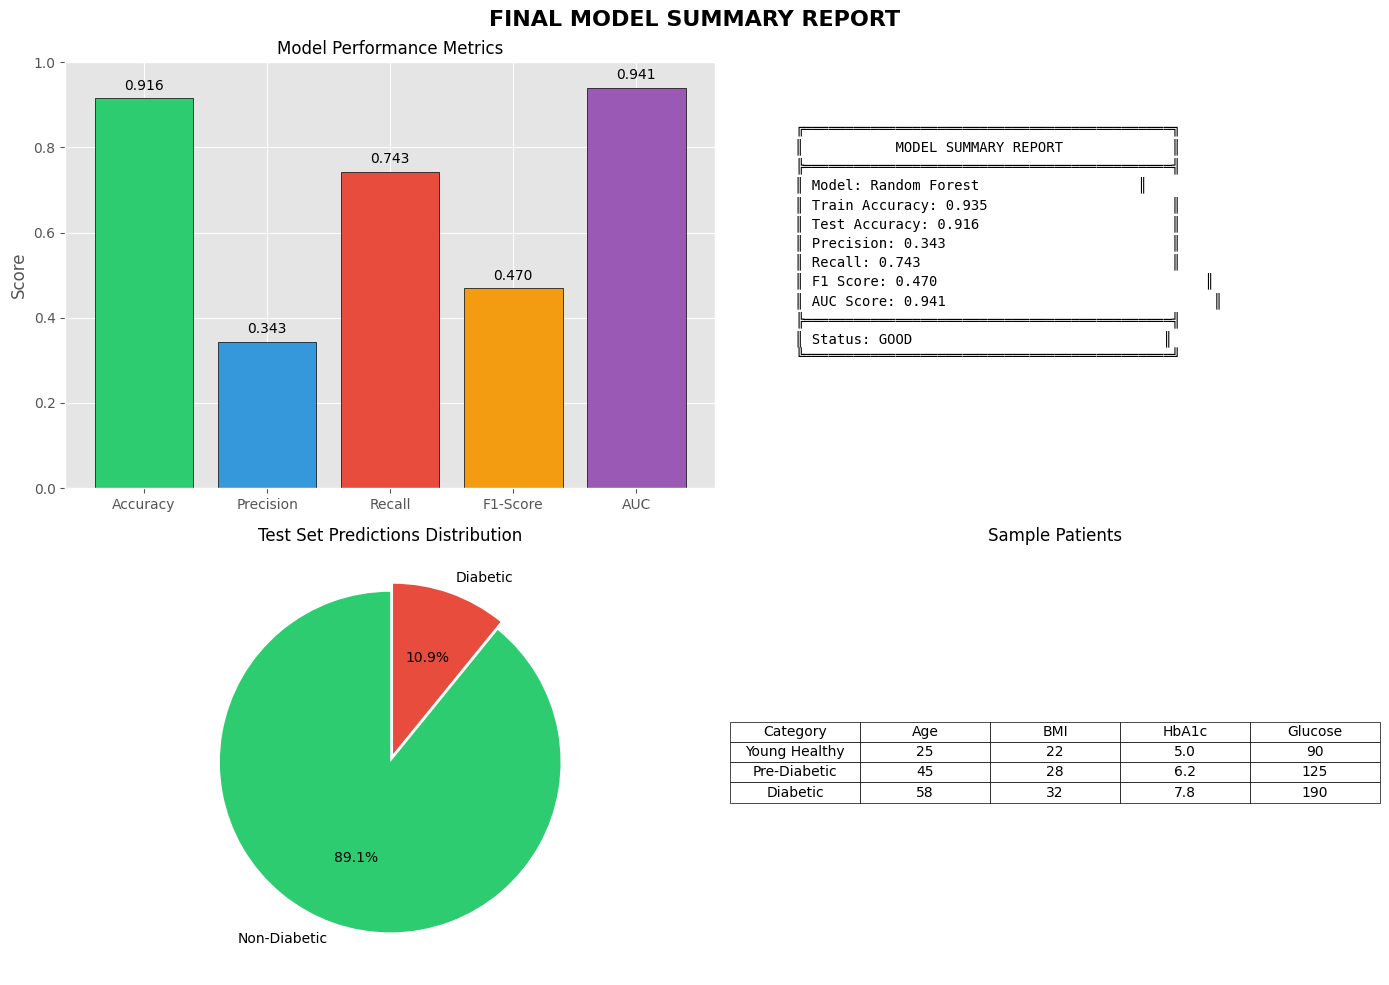


PROJECT COMPLETED SUCCESSFULLY!

Files generated:
  • outlier_boxplots.png
  • confusion_matrix.png
  • roc_curve.png
  • feature_importance.png
  • final_summary_graph.png
  • diabetes_prediction_model.pkl
  • diabetes_scaler.pkl
  • feature_columns.pkl


In [21]:
# Cell 19: Final Summary Graph
print("="*60)
print("FINAL SUMMARY")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Model Performance
metrics_data = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
metrics_values = [test_accuracy, precision, recall, f1, roc_auc]
colors_bar = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6']
bars = axes[0, 0].bar(metrics_data, metrics_values, color=colors_bar, edgecolor='black')
axes[0, 0].set_ylim(0, 1)
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_title('Model Performance Metrics', fontsize=12)
for bar, val in zip(bars, metrics_values):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{val:.3f}', ha='center', fontsize=10)

# 2. Summary Table
axes[0, 1].axis('off')
summary_text = f"""
╔════════════════════════════════════════════╗
║           MODEL SUMMARY REPORT             ║
╠════════════════════════════════════════════╣
║ Model: {best_model_name:<30}  ║
║ Train Accuracy: {train_accuracy:.3f}                      ║
║ Test Accuracy: {test_accuracy:.3f}                       ║
║ Precision: {precision:.3f}                           ║
║ Recall: {recall:.3f}                              ║
║ F1 Score: {f1:.3f}                                ║
║ AUC Score: {roc_auc:.3f}                                ║
╠════════════════════════════════════════════╣
║ Status: {'GOOD' if test_accuracy > 0.8 else ' OK'}                              ║
╚════════════════════════════════════════════╝
"""
axes[0, 1].text(0.1, 0.9, summary_text, fontsize=10, fontfamily='monospace', verticalalignment='top')

# 3. Predictions Distribution
pred_counts = pd.Series(y_test_pred).value_counts()
colors_pred = ['#2ecc71', '#e74c3c']
axes[1, 0].pie(pred_counts.values, labels=['Non-Diabetic', 'Diabetic'], autopct='%1.1f%%',
               colors=colors_pred, startangle=90, explode=(0, 0.05))
axes[1, 0].set_title('Test Set Predictions Distribution', fontsize=12)

# 4. Sample Predictions
sample_data = [
    ["Young Healthy", 25, 22, 5.0, 90],
    ["Pre-Diabetic", 45, 28, 6.2, 125],
    ["Diabetic", 58, 32, 7.8, 190],
]
sample_table = axes[1, 1].table(cellText=sample_data,
                                 colLabels=['Category', 'Age', 'BMI', 'HbA1c', 'Glucose'],
                                 loc='center', cellLoc='center')
sample_table.auto_set_font_size(False)
sample_table.set_fontsize(10)
axes[1, 1].axis('off')
axes[1, 1].set_title('Sample Patients', fontsize=12)

plt.suptitle('FINAL MODEL SUMMARY REPORT', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('final_summary_graph.png', dpi=200, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("PROJECT COMPLETED SUCCESSFULLY!")
print("="*60)
print("\nFiles generated:")
print("  • outlier_boxplots.png")
print("  • confusion_matrix.png")
print("  • roc_curve.png")
print("  • feature_importance.png")
print("  • final_summary_graph.png")
print("  • diabetes_prediction_model.pkl")
print("  • diabetes_scaler.pkl")
print("  • feature_columns.pkl")

**Interactive Prediction**

In [22]:
# Cell 20: Interactive prediction (Run this cell to get user input)
print("="*60)
print("INTERACTIVE DIABETES PREDICTION")
print("="*60)

def interactive_predict():
    print("\nEnter patient health data:")
    print("-" * 40)

    try:
        age = float(input("Age (years): "))
        bmi = float(input("BMI: "))
        hba1c = float(input("HbA1c level (4-9): "))
        glucose = float(input("Blood glucose level (mg/dL): "))

        result, risk = predict_diabetes(age, bmi, hba1c, glucose)

        print("\n" + "="*40)
        print("PREDICTION RESULT")
        print("="*40)
        print(f"Result: {result}")
        print(f"Risk: {risk}")

        if result == "Diabetic":
            print("\nPlease consult a healthcare professional.")
        else:
            print("\n Maintain a healthy lifestyle.")

    except ValueError:
        print(" Please enter valid numbers!")

# Uncomment to run interactive prediction
# interactive_predict()

INTERACTIVE DIABETES PREDICTION


**For Checking**

In [35]:
result, risk = predict_diabetes(65, 22, 4.9, 100)
print(f"Result: {result}, Risk: {risk}")

Result: Non-Diabetic, Risk: 0.9%
